In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import sys

from itertools import combinations

sys.path.insert(0, "..")

In [26]:
variance_opt_data = pd.read_csv(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_var_opt_data.txt",
delimiter=" ")

commutator_opt_data = pd.read_csv(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_comm_opt_data.txt",
delimiter=" ")

commutator_opt_data_hf = pd.read_csv(
    "../outputs/H4_linear_d2.5560_20260505_131450_comm_opt_data.txt",
delimiter=" ", skiprows=1)

In [27]:
optimized_value_indices = ["V_optimized", "Sum_CommSq_Optimized", "b_opt", "c_opt"]

In [28]:
np.all(np.isclose(commutator_opt_data[optimized_value_indices].iloc[0], 
           commutator_opt_data[optimized_value_indices].iloc[2], atol=1e-3))

True

In [29]:
def same_minimum(i, j, df, tol=1e-3) -> bool: 
    return np.all(np.isclose(df[optimized_value_indices].iloc[i], 
           df[optimized_value_indices].iloc[j], atol=tol))

In [30]:
variance_graph = nx.Graph()
variance_graph.add_nodes_from(range(variance_opt_data.shape[0]))
for i, j in combinations(variance_graph.nodes, 2):
    if same_minimum(i, j, variance_opt_data, tol=1e-3):
        variance_graph.add_edge(i, j)

distinct_var_minima = [min(comp) for comp in nx.connected_components(variance_graph)]
var_minima_hit_counts = [len(comp) for comp in nx.connected_components(variance_graph)]

variance_minima = variance_opt_data[optimized_value_indices].iloc[distinct_var_minima]
variance_minima["hits"] = var_minima_hit_counts
variance_minima

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.041484,0.000451,1.000011,-1.954296,13
3,0.005052,0.001709,0.999993,-1.418657,7
7,0.023559,0.001193,1.000011,-1.948301,9
14,0.081616,0.114773,0.999995,-1.933690,1


In [31]:
w = np.where(commutator_opt_data["V_0"] < commutator_opt_data["V_optimized"])[0]

commutator_opt_data.iloc[w]

,E_FCI,V_0,V_optimized,Sum_CommSq_0,Sum_CommSq_Optimized,a_opt,b_opt,c_opt
3,-1.871168,0.891383,1.982571,0.362018,0.000562,1.0,-1.000229,0.000083
4,-1.871168,1.013283,1.982571,0.385303,0.000562,1.0,-0.999935,-0.000274
5,-1.871168,0.466511,1.982570,0.186955,0.000562,1.0,-1.000208,-0.000241
12,-1.871168,0.981554,1.982568,0.418032,0.000562,1.0,-0.998920,-0.000170
19,-1.871168,1.618059,1.982570,0.542919,0.000562,1.0,-1.000997,0.000206
20,-1.871168,1.208258,1.982570,0.445861,0.000562,1.0,-0.999365,-0.000677
26,-1.871168,0.767323,1.982570,0.275539,0.000562,1.0,-1.000334,0.000653
27,-1.871168,0.679172,1.982571,0.265159,0.000562,1.0,-1.000022,-0.000024


In [32]:
print(variance_minima)

    V_optimized  Sum_CommSq_Optimized     b_opt     c_opt  hits
0      0.041484              0.000451  1.000011 -1.954296    13
3      0.005052              0.001709  0.999993 -1.418657     7
7      0.023559              0.001193  1.000011 -1.948301     9
14     0.081616              0.114773  0.999995 -1.933690     1


In [33]:
comm_graph = nx.Graph()
comm_graph.add_nodes_from(range(commutator_opt_data.shape[0]))
for i, j in combinations(comm_graph.nodes, 2):
    if same_minimum(i, j, commutator_opt_data, tol=1e-3):
        comm_graph.add_edge(i, j)

comm_var_minima = [min(comp) for comp in nx.connected_components(comm_graph)]
comm_minima_hit_counts = [len(comp) for comp in nx.connected_components(comm_graph)]

comm_minima = commutator_opt_data[optimized_value_indices].iloc[comm_var_minima]
comm_minima["hits"] = comm_minima_hit_counts
comm_minima

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.023745,0.001118,0.999997,-1.991831,10
1,0.025023,0.001919,0.999966,-1.888901,3
3,1.982571,0.000562,-1.000229,0.000083,8
6,0.045171,0.001953,1.000024,-1.936872,1
8,0.041845,0.000303,0.999473,-1.997689,3
11,0.085084,0.001314,1.000030,-1.981177,3
13,0.086349,0.001740,1.000024,-1.983794,2


In [34]:
print(comm_minima)

    V_optimized  Sum_CommSq_Optimized     b_opt     c_opt  hits
0      0.023745              0.001118  0.999997 -1.991831    10
1      0.025023              0.001919  0.999966 -1.888901     3
3      1.982571              0.000562 -1.000229  0.000083     8
6      0.045171              0.001953  1.000024 -1.936872     1
8      0.041845              0.000303  0.999473 -1.997689     3
11     0.085084              0.001314  1.000030 -1.981177     3
13     0.086349              0.001740  1.000024 -1.983794     2


In [35]:
comm_graph_hf = nx.Graph()
comm_graph_hf.add_nodes_from(range(commutator_opt_data_hf.shape[0]))
for i, j in combinations(comm_graph_hf.nodes, 2):
    if same_minimum(i, j, commutator_opt_data_hf, tol=1e-3):
        comm_graph_hf.add_edge(i, j)

comm_minima_hf = [min(comp) for comp in nx.connected_components(comm_graph_hf)]
comm_minima_hf_hit_counts = [len(comp) for comp in nx.connected_components(comm_graph_hf)]

comm_minima_hf = commutator_opt_data_hf[optimized_value_indices].iloc[comm_minima_hf]
comm_minima_hf["hits"] = comm_minima_hf_hit_counts
comm_minima_hf

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.086872,0.001489,0.998249,-1.987780,1
1,0.158918,0.004076,1.000007,-1.819580,6
2,0.086877,0.001489,1.000482,-1.990111,7
3,0.245554,0.001509,0.999896,-1.013484,5
4,0.000064,0.000731,0.999858,-1.997333,7
7,0.086873,0.001489,1.001922,-1.991542,1
13,0.158709,0.005676,1.000004,-1.821237,1
21,0.000037,0.000731,0.998463,-1.995965,1
22,0.157252,0.005104,0.999807,-1.765404,1


In [51]:
for i in range(comm_minima_hf.shape[0]):
    row = comm_minima_hf.iloc[i]
    w = ["{0:2.6f}".format(x) if type(x) == float else "{0:}".format(x)
         for x in row]
    print(" & ".join(w) + r" \\")
    # for x in row:
    #     print(x)
    # print()

0.086872 & 0.001489 & 0.998249 & -1.987780 & 1.000000 \\
0.158918 & 0.004076 & 1.000007 & -1.819580 & 6.000000 \\
0.086877 & 0.001489 & 1.000482 & -1.990111 & 7.000000 \\
0.245554 & 0.001509 & 0.999896 & -1.013484 & 5.000000 \\
0.000064 & 0.000731 & 0.999858 & -1.997333 & 7.000000 \\
0.086873 & 0.001489 & 1.001922 & -1.991542 & 1.000000 \\
0.158709 & 0.005676 & 1.000004 & -1.821237 & 1.000000 \\
0.000037 & 0.000731 & 0.998463 & -1.995965 & 1.000000 \\
0.157252 & 0.005104 & 0.999807 & -1.765404 & 1.000000 \\


In [53]:
row

V_optimized             0.157252
Sum_CommSq_Optimized    0.005104
b_opt                   0.999807
c_opt                  -1.765404
hits                    1.000000
Name: 22, dtype: float64

In [44]:
print(comm_minima_hf)

    V_optimized  Sum_CommSq_Optimized     b_opt     c_opt  hits
0      0.086872              0.001489  0.998249 -1.987780     1
1      0.158918              0.004076  1.000007 -1.819580     6
2      0.086877              0.001489  1.000482 -1.990111     7
3      0.245554              0.001509  0.999896 -1.013484     5
4      0.000064              0.000731  0.999858 -1.997333     7
7      0.086873              0.001489  1.001922 -1.991542     1
13     0.158709              0.005676  1.000004 -1.821237     1
21     0.000037              0.000731  0.998463 -1.995965     1
22     0.157252              0.005104  0.999807 -1.765404     1


In [36]:
commutator_opt_data_hf.shape

(30, 8)

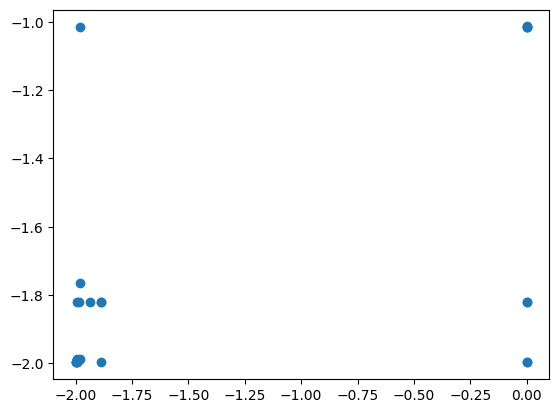

In [43]:
plt.scatter(commutator_opt_data["c_opt"], commutator_opt_data_hf["c_opt"])

In [55]:
variance_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_x_var_opt.txt")
commutator_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_x_comm_opt.txt")
commutator_hf_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.5560_20260505_131450_x_comm_opt.txt")

In [59]:
commutator_hf_opt_x.shape

(30, 8)

In [60]:
dxs = commutator_hf_opt_x - commutator_opt_x
np.linalg.norm(dxs, axis=1)

array([ 0.04687371,  0.13298847,  0.06242163,  1.68952608,  2.4546667 ,
        2.30689562,  1.83747704,  0.04789879,  2.91044482,  0.7148584 ,
        0.87614021,  1.36929083,  1.69005245,  0.04247552,  1.25321593,
        2.01122697,  0.09919526,  0.04630158,  0.04703073,  2.00285388,
        1.68897677,  3.37072684,  0.05831021,  1.61180339,  0.05480054,
        1.18988323,  2.13881549, 16.01682201,  1.94881639,  1.45428588])

In [62]:
commutator_opt_data.iloc[np.argmin(commutator_opt_data["Sum_CommSq_Optimized"])]

E_FCI                  -1.871168
V_0                     0.490930
V_optimized             0.041845
Sum_CommSq_0            0.160924
Sum_CommSq_Optimized    0.000303
a_opt                   1.000000
b_opt                   0.999847
c_opt                  -1.998070
Name: 29, dtype: float64

In [63]:
commutator_opt_data_hf.iloc[np.argmin(commutator_opt_data_hf["Sum_CommSq_Optimized"])]

E_FCI                  -1.871168
V_0                     0.520950
V_optimized             0.000064
Sum_CommSq_0            0.249891
Sum_CommSq_Optimized    0.000731
a_opt                   1.000000
b_opt                   0.999858
c_opt                  -1.997333
Name: 4, dtype: float64

In [64]:
np.argmin(commutator_opt_data_hf["Sum_CommSq_Optimized"])

4

In [65]:
commutator_opt_data_hf.iloc[29]

E_FCI                  -1.871168
V_0                     0.268925
V_optimized             0.000018
Sum_CommSq_0            0.111960
Sum_CommSq_Optimized    0.000732
a_opt                   1.000000
b_opt                   0.999922
c_opt                  -1.997416
Name: 29, dtype: float64

In [66]:
commutator_opt_data.iloc[4]

E_FCI                  -1.871168
V_0                     1.013283
V_optimized             1.982571
Sum_CommSq_0            0.385303
Sum_CommSq_Optimized    0.000562
a_opt                   1.000000
b_opt                  -0.999935
c_opt                  -0.000274
Name: 4, dtype: float64

In [68]:
from chemistry import build_U_from_thetas

In [70]:
n = 4
pairs = list(combinations(range(n), 2))
len(pairs)

6

In [72]:
Us_fci = [build_U_from_thetas(n, commutator_opt_x[i, :], pairs)
          for i in range(commutator_opt_x.shape[0])]

Us_hf = [build_U_from_thetas(n, commutator_hf_opt_x[i, :], pairs)
          for i in range(commutator_hf_opt_x.shape[0])]

In [75]:
Us_fci[4]

array([[ 0.54924362,  0.54924809,  0.44535231,  0.44533054],
       [-0.44589234,  0.44586157,  0.54881453, -0.54880789],
       [-0.44532212, -0.44536074,  0.54924574,  0.54924598],
       [-0.54881661,  0.5488058 , -0.44586214,  0.44589177]])

In [76]:
Us_hf[4]

array([[ 0.70708872,  0.00504313,  0.70708879, -0.00505461],
       [-0.7070908 , -0.0047645 ,  0.70709058, -0.0047754 ],
       [ 0.00504344, -0.70709105,  0.00505431,  0.70708646],
       [-0.00476419,  0.70708847,  0.0047757 ,  0.70709291]])

In [77]:
Us_fci[29]

array([[ 0.07112852, -0.07115093,  0.70351495, -0.70352327],
       [-0.06989418, -0.06988565, -0.70364922, -0.70363952],
       [-0.70350661,  0.70353161,  0.07114226, -0.0711372 ],
       [ 0.70365758,  0.70363116, -0.06988046, -0.06989937]])

In [78]:
Us_hf[29]

array([[-1.20871457e-04, -4.34357018e-03,  7.07213697e-01,
        -7.06986496e-01],
       [ 1.15762238e-04, -2.88781191e-03, -7.06999079e-01,
        -7.07208562e-01],
       [-7.06990409e-01,  7.07213639e-01,  6.10259523e-04,
        -3.61363793e-03],
       [ 7.07223115e-01,  7.06980667e-01,  8.46654137e-04,
        -3.61752005e-03]])

In [81]:
import h5py

In [84]:
hamiltonian_data = h5py.File("../hamiltonians/H4_sto-3g_singlet_H4_linear_d2.5560.hdf5",
                             "r")

In [89]:
list(hamiltonian_data.keys())

['atoms',
 'basis',
 'canonical_orbitals',
 'ccsd_double_amps',
 'ccsd_energy',
 'ccsd_single_amps',
 'charge',
 'cisd_energy',
 'cisd_one_rdm',
 'cisd_two_rdm',
 'description',
 'fci_energy',
 'fci_one_rdm',
 'fci_two_rdm',
 'general_calculations_keys',
 'general_calculations_values',
 'geometry',
 'hf_energy',
 'mp2_energy',
 'multiplicity',
 'n_atoms',
 'n_electrons',
 'n_orbitals',
 'n_qubits',
 'name',
 'nuclear_repulsion',
 'one_body_integrals',
 'orbital_energies',
 'overlap_integrals',
 'protons',
 'two_body_integrals']

In [97]:
canonical_orbitals = np.array(hamiltonian_data["canonical_orbitals"])

In [101]:
canonical_orbitals

array([[ 0.43317622, -0.53909244,  0.55974397,  0.45871166],
       [ 0.52865089, -0.44370604, -0.44734677, -0.57229539],
       [ 0.52865089,  0.44370604, -0.44734677,  0.57229539],
       [ 0.43317622,  0.53909244,  0.55974397, -0.45871166]])

In [104]:
canonical_orbitals @ Us_fci[4]

array([[-2.27184831e-02,  1.62350630e-05, -3.09008776e-05,
         1.00073766e+00],
       [ 1.00150188e+00, -2.23193207e-02,  1.38511789e-03,
        -2.19514561e-02],
       [-2.23587968e-02,  1.00150168e+00, -2.19199407e-02,
         1.39340510e-03],
       [ 2.42906371e-05, -2.27497869e-02,  1.00073695e+00,
        -5.02080803e-05]])